Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [864]:
Group = "G5"
NAME = "G5"
COLLABORATORS = "Tananon Termteerapornpimol,Wachirawit Piyaprapapan,Krittipong Luengniyomkul,Kittapas Yukhlai"

---

## Outlier diagnostics

This notebook provides: 

- [Tools and packages](#tools-and-packages) 
    - [Data processing](#data-loading-preprocessing-and-visualization)
- [Outlier analysis](#outlier-analysis)
    - [H-matrix](#h-matrix)   
    - [Cook's distance](#cooks-distance)
- Your tasks are to compair and discuss the difference between these methods
    - [Performance compairison](#performance-compairison)
    - [Are the outliers of the two methods intersect](#are-the-outliers-of-the-two-methods-intersect)
    - [How is the performance improved by the two outlier removals](#how-is-the-performance-improvement-by-the-two-outlier-removals)

You can run this notebook on collab:  <a target="_blank" href="https://colab.research.google.com/github/GenAI-CUEE/Statistical-Learning-EE575-Y2024/blob/master/Lab2/outlier_diagnostics.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Tools and Packages

In [865]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns


def train_validate_test_split(df, train_percent=0.6, validate_percent=0.2, seed=None):
    np.random.seed(seed)
    perm = np.random.permutation(df.index)
    m = len(df.index)
    train_end = np.floor(int(train_percent * m))
    validate_end = np.floor(int(validate_percent * m) + train_end)

    train = df.iloc[perm[:train_end]]
    validate = df.iloc[perm[train_end:validate_end]]
    test = df.iloc[perm[validate_end:]]

    train = train.drop(columns=["index"])
    validate = validate.drop(columns=["index"])
    test = test.drop(columns=["index"])

    train = train.reset_index(drop=True)
    validate = validate.reset_index(drop=True)
    test = test.reset_index(drop=True)

    return train, validate, test

In [866]:
foldername = "house-prices-advanced-regression-techniques"
df = pd.read_csv("%s/train.csv" % foldername)

### Data loading, preprocessing, and visualization

In [867]:
target_column = ["SalePrice"]
feat_column = ["MoSold", "YrSold", "MSZoning", "LandSlope", "2ndFlrSF", "CentralAir", "TotRmsAbvGrd", "TotalBsmtSF", "GrLivArea", "BldgType", "OverallCond", "BsmtHalfBath", "ScreenPorch"]

all_column = target_column + feat_column

In [868]:
df = df[all_column]
df = df.apply(LabelEncoder().fit_transform)

df = df.dropna()
df = df.reset_index()

In [869]:
train, valid, test = train_validate_test_split(df, train_percent=0.8, validate_percent=0, seed=None)

### 🧠 The `StandardScaler` Workflow

**1. `fit()` = Learn Statistics**
Calculates the mean ($\mu$) and standard deviation ($\sigma$). It "studies" the data but doesn't change it.

**2. `transform()` = Apply Scaling**
Uses the learned stats to shift and scale the data:
$$\mathbf{x}' = \frac{\mathbf{x} - \mu}{\sigma}$$

**3. `fit_transform()` = The Shortcut**
Performs both steps in a single, efficient operation.
 

In [870]:
X_scaler = StandardScaler()
train[feat_column].values[:] = X_scaler.fit_transform(train[feat_column].values[:])
test[feat_column].values[:] = X_scaler.transform(test[feat_column].values[:])
# valid[feat_column].values[:] = X_scaler.transform(valid[feat_column].values[:])

In [871]:
data_column = target_column + feat_column
train_enc = train.loc[:, data_column]

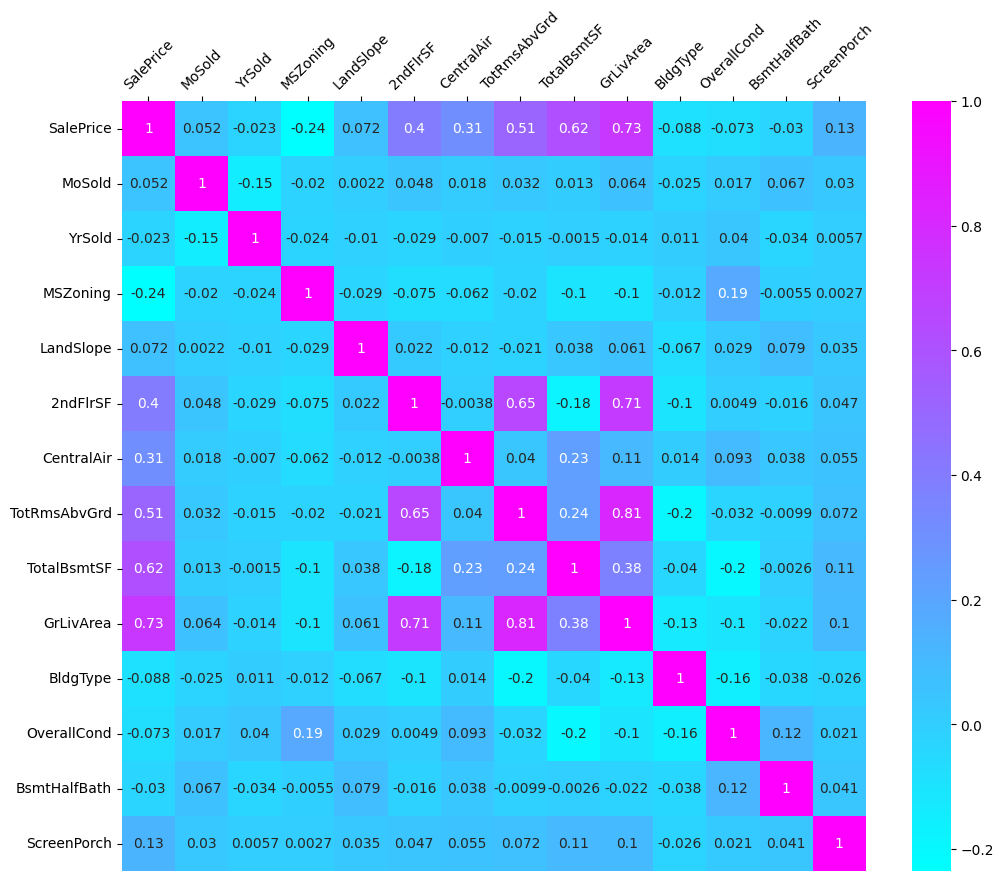

In [872]:
plt.figure(figsize=(12, 10))
cor = train_enc.corr()
g = sns.heatmap(cor, annot=True, cmap=plt.cm.cool)
g.axes.xaxis.set_ticks_position("top")
plt.setp(g.axes.get_xticklabels(), rotation=45)
plt.show()

## Outlier analysis

### Settings

In [873]:
target_column = ["SalePrice"]
feat_column = ["GrLivArea"]
outliers_percentile = 5

### H-matrix

Let $X$ be an array of training data. Then, H-matrix is defined by 
$$ H = X (X^T X)^{-1} X^T $$

Write the function `H_matrix_leverage() ` using `X_train` to compute the diagonal entries of the H matrix.  

In [874]:
train.loc[:, feat_column].values

array([[801],
       [818],
       [348],
       ...,
       [131],
       [509],
       [585]], shape=(1168, 1))

In [875]:
def H_matrix_leverage(X_train):
    try:
        h = X_train @ np.linalg.inv(X_train.T @ X_train) @ X_train.T
        H_diag = np.diag(h)
    except Exception:
        raise NotImplementedError()
    return H_diag

In [876]:
X_train = train.loc[:, feat_column].values
[num_samples, num_feats] = X_train.shape

H_diag = H_matrix_leverage(X_train)

Plot diagonal entries of hat matrix

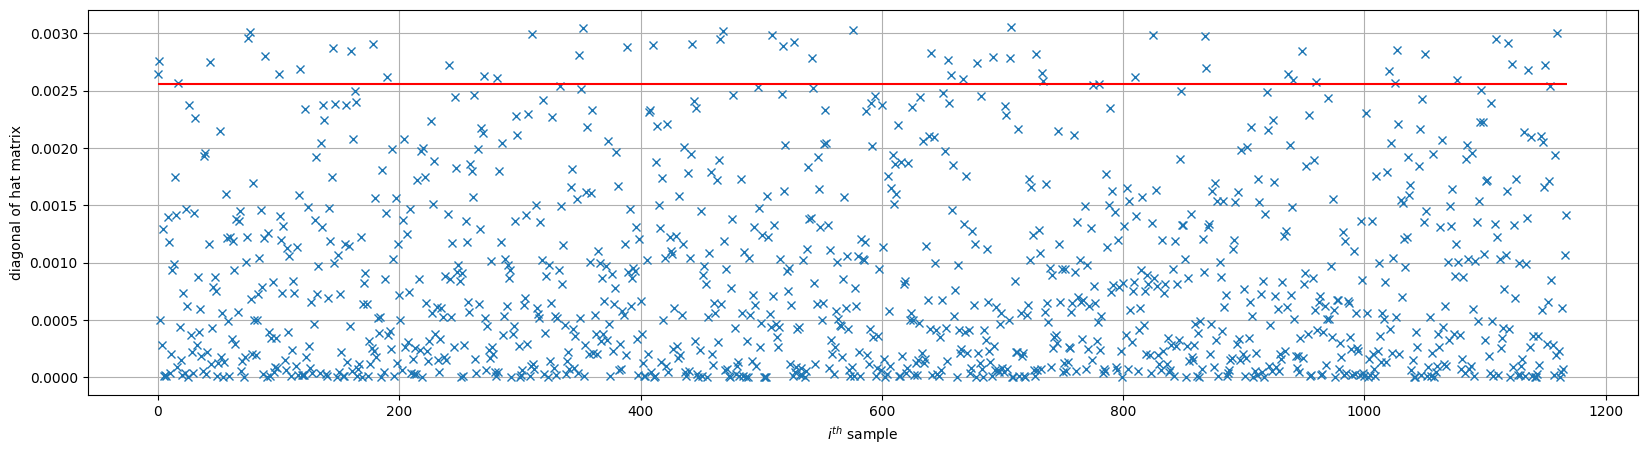

In [877]:
p_H = np.percentile(H_diag, 100 - outliers_percentile)

plt.figure(figsize=(20, 5))
plt.plot(H_diag, marker="x", ls="none")
plt.hlines(p_H, xmin=0, xmax=len(H_diag), colors="red")
plt.xlabel("$i^{th}$ sample")
plt.ylabel("diagonal of hat matrix")
plt.grid()

### Cook's distance

Each entry in the Cook's distance vector is defined by 
$$ D_j = \frac{e^2_j \cdot h_{j,j}}{m \cdot \text{MSE}_{y}(\hat{y}) \cdot (1-h_{j,j})^2} $$

where each components are calculated using the following variables:

$[h_{j,j}]_{j = 1:m}$ := `H_diag`

$[e^2_j]_{j = 1:m}$ := `e_train`

$\text{MSE}_{y}(\hat{y})$ := `mse_train`

Here we will provide `e_train` and `mse_train` for you. 

In [878]:
from sklearn.linear_model import LinearRegression

X_train = train[feat_column].values
y_train = train[target_column].values

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_train_predict = model_lr.predict(X_train)

e_train = (y_train - y_train_predict).reshape(-1)
mse_train = np.mean((y_train - y_train_predict) ** 2)

Write the function `CookDistance()` using `e_train, mse_train, H_diag, num_feats` to compute Cook's distance vector. 

In [879]:
def CookDistance(residuals, mse, leverage, p):
    # Calculate the components
    numerator = (residuals**2) * leverage
    denominator = p * mse * (1 - leverage) ** 2

    return numerator / denominator

In [880]:
Cook_D = CookDistance(e_train, mse_train, H_diag, num_feats)

Plot Cook's distance entries 

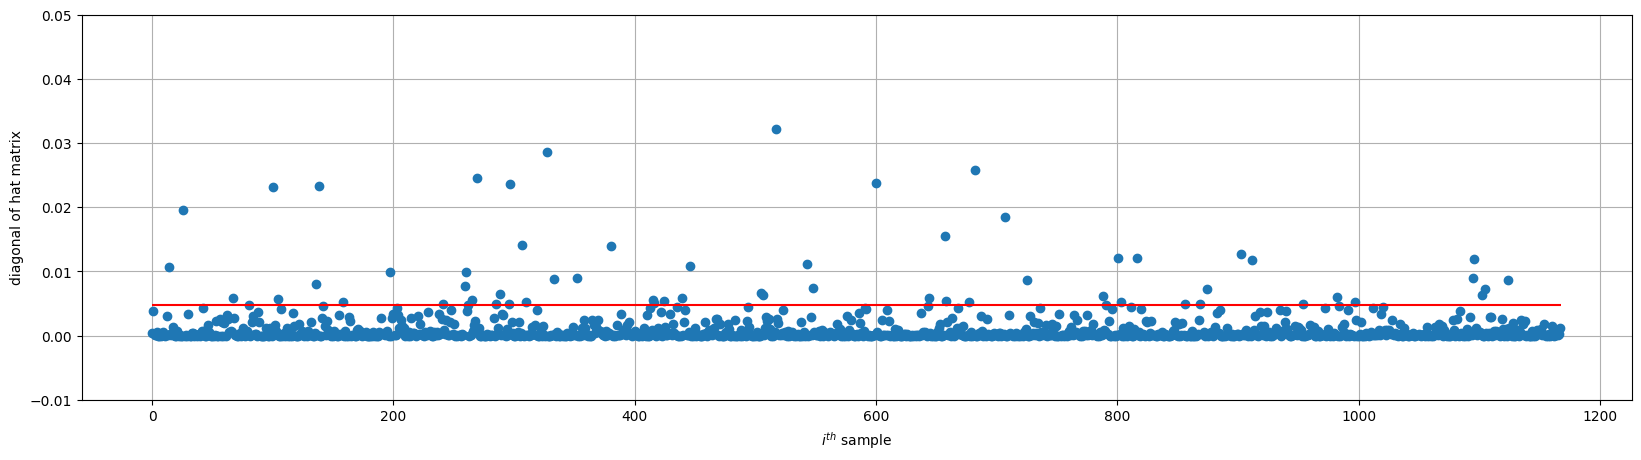

In [881]:
p_D = np.percentile(Cook_D, 100 - outliers_percentile)

plt.figure(figsize=(20, 5))
plt.plot(Cook_D, marker="o", ls="none")
plt.hlines(p_D, xmin=0, xmax=len(Cook_D), colors="red")
plt.xlabel("$i^{th}$ sample")
plt.ylabel("diagonal of hat matrix")
plt.ylim([-0.01, 0.05])
plt.grid()

### Performance compairison

#### Are the outliers of the two methods intersect?

In [882]:
X_train_H = X_train[H_diag <= p_H, :]
Y_train_H = y_train[H_diag <= p_H]

X_train_H_outliers = X_train[H_diag > p_H, :]
Y_train_H_outliers = y_train[H_diag > p_H]


X_train_Cooks = X_train[Cook_D <= p_D, :]
Y_train_Cooks = y_train[Cook_D <= p_D]
X_train_Cooks_outliers = X_train[Cook_D > p_D, :]
Y_train_Cooks_outliers = y_train[Cook_D > p_D]

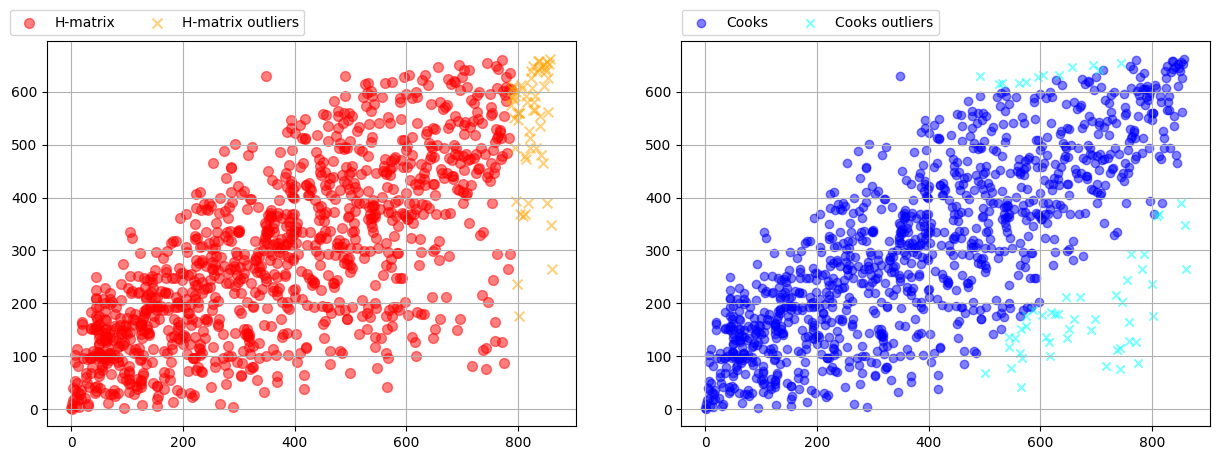

In [883]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_H, Y_train_H, color="red", marker="o", label="H-matrix", s=50, alpha=0.5)
plt.scatter(X_train_H_outliers, Y_train_H_outliers, color="orange", marker="x", label="H-matrix outliers", s=50, alpha=0.5)
plt.legend(bbox_to_anchor=(0.50, 1.1), ncol=2)
plt.grid()

plt.subplot(1, 2, 2)
plt.scatter(X_train_Cooks, Y_train_Cooks, color="blue", label="Cooks", alpha=0.5)
plt.scatter(X_train_Cooks_outliers, Y_train_Cooks_outliers, color="cyan", marker="x", label="Cooks outliers", alpha=0.5)
plt.xlabel("")
plt.legend(bbox_to_anchor=(0.50, 1.1), ncol=2)
plt.grid()

#### How is the performance improvement by the two outlier removals?

Get the testing set

In [884]:
X_test = test[feat_column].values
y_test = test[target_column].values

Before outlier removal

In [885]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Test on testing set

In [886]:
y_predict_test = model_lr.predict(X_test)

After outlier removal by H-matrix

In [887]:
model_lr_H = LinearRegression()
model_lr_H.fit(X_train_H, Y_train_H)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [888]:
y_predict_H_test = model_lr_H.predict(X_test)

After outlier removal by Cook's distance

In [889]:
model_lr_D = LinearRegression()
model_lr_D.fit(X_train_Cooks, Y_train_Cooks)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [890]:
y_predict_D_test = model_lr_D.predict(X_test)

Evaluations:

In [891]:
MSE_before = np.sqrt(np.mean((y_predict_test - y_test) ** 2))
MSE_after_H = np.sqrt(np.mean((y_predict_H_test - y_test) ** 2))
MSE_after_D = np.sqrt(np.mean((y_predict_D_test - y_test) ** 2))

In [ ]:
def get_r2(y_test, y_predict_test):
    y_test_mean = np.mean(y_test)
    ssr = np.sum((y_test - y_predict_test) ** 2)
    sst = np.sum((y_test - y_test_mean) ** 2)

    r2 = 1 - (ssr / sst)
    return r2


r2_before = get_r2(y_test, y_predict_test)
r2_after_H = get_r2(y_test, y_predict_H_test)
r2_after_D = get_r2(y_test, y_predict_D_test)

In [893]:
print("MSE [before] = %.2f" % MSE_before)
print("r2 [before] = %.2f" % r2_before)

print("MSE [after using H-matrix]     = %.2f" % MSE_after_H)
print("r2 [after using H-matrix]     = %.2f" % r2_after_H)

print("MSE [after using Cook's Dist.] = %.2f" % MSE_after_D)
print("r2 [after using Cook's Dist.] = %.2f" % r2_after_D)

MSE [before] = 113.61
r2 [before] = 0.55
MSE [after using H-matrix]     = 113.57
r2 [after using H-matrix]     = 0.55
MSE [after using Cook's Dist.] = 115.38
r2 [after using Cook's Dist.] = 0.54


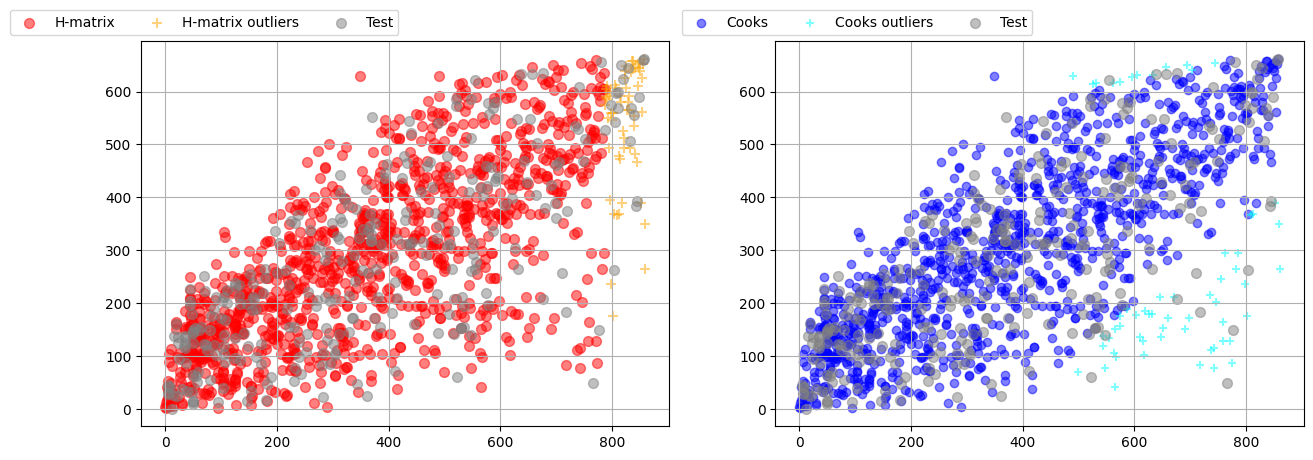

In [894]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_H, Y_train_H, color="red", marker="o", label="H-matrix", s=50, alpha=0.5)
plt.scatter(X_train_H_outliers, Y_train_H_outliers, color="orange", marker="+", label="H-matrix outliers", s=50, alpha=0.5)
plt.scatter(X_test, y_test, color="grey", marker="o", label="Test", s=50, alpha=0.5)

plt.legend(bbox_to_anchor=(0.50, 1.1), ncol=3)
plt.grid()

plt.subplot(1, 2, 2)
plt.scatter(X_train_Cooks, Y_train_Cooks, color="blue", label="Cooks", alpha=0.5)
plt.scatter(X_train_Cooks_outliers, Y_train_Cooks_outliers, color="cyan", marker="+", label="Cooks outliers", alpha=0.5)
plt.scatter(X_test, y_test, color="grey", marker="o", label="Test", s=50, alpha=0.5)

plt.xlabel("")
plt.legend(bbox_to_anchor=(0.50, 1.1), ncol=3)
plt.grid()

## H-Matrix (Leverage)
**Definition:** Measures how extreme a specific observation is in the feature space ($X$-space).
*  Depends solely on the **$X$ (inputs)**; it does not care about the target $y$.
* High leverage points are "unusual" predictor values that have the *potential* to pull the regression line toward them.
*  Detects **structural outliers** and it's usually be high values samples.

**Formula:**
$$h_{ii} = \mathbf{x}_i^T (X^T X)^{-1} \mathbf{x}_i$$

 
##  Cook’s Distance
**Definition:** Measures the actual **influence** a point has on the model's coefficients. It asks: *"If I delete this point, how much do my predictions change?"*
*  Uses both **$X$ and $y$**.
* It is a product of  
    - Leverage:  How far the point is from the center.
    - Residual size: How poorly the model predicts that specific point.
* **Focus:** Detects **influential outliers**.

**Formula:**
$$D_i = \frac{e_i^2}{p \cdot \text{MSE}} \cdot \left[ \frac{h_{ii}}{(1 - h_{ii})^2} \right]$$

 
**Q2.a Do the detected outliers intersect?**

Yes, partial overlap expected because:

* Cook’s Distance includes leverage as a factor

* High-leverage points often appear in both but not all leverage points are influential.

**Q2.b Are there any outliers identified that have been chosen differently by each of the methods?**

Totally, because:

* Cook’s Distance use both leverage and MSE in formula. So Cook's outlier's is the point that both have high leverage and greatly deviates from norm.
* Hat matrix alone use only leverage so it will identify only samples that have high values only but it may and may not deviate much form norm like Cook's.


**Q2.c How is the performance improved by removing the outliers identified by H-matrix versus the Cook's distance ?**

* Cook's Distance > Hat Matrix > Original data becaues:
- After removing high-leverage points identified by the H-matrix, the model showed a modest improvement. The RMSE decreased from 113.61 → 113.57, and R² almost the same. This suggests that leverage-based filtering improves stability but does not always remove harmful observations.
- While, removing outliers based on Cook’s Distance did not lead to a more significant performance gain. RMSE incrased to 115.38, and R² almost the same. This not aligns with theory, since Cook’s Distance targets points that directly influence model parameters so when the test dataset have bad outliers, the model can't predict those correctly but if our samples larger, the result.